# Análise das redes de mobilidade

Redes geradas pelo https://github.com/pedrospeixoto/mdyn com dados de mobilidade da empresa Inloco. Dados sob responsabilidade de Pedro Peixoto (IME/USP).

As redes de mobilidade foram obtidas no computador `parisi` do GISC da UFV (https://giscbr.org.br) por Wesley Cota (https://wcota.me/).

Este notebook contém algumas análises preliminares avulsas.

Geramos as seguintes redes a partir dos shapefiles de zonas e subprefeituras da cidade de São Paulo:

- ` `: mapas originais
- `_super`: contém as zonas/subprefeituras + municípios de SP + todos os demais estados e DF
- `_superBR`: contém as zonas/subprefeituras + o restante do Brasil (sem a cidade de SP)

## Dúvidas nos dados:

- [ ] Por que não há dados fora da diagonal nos mapas originais?
- [ ] As redes `_super` e `_superBR` são equivalentes, caso os municípios, estados e DF sejam agregados? Isso não foi conferido.

## Definições de caminhos dos dados

Defina aqui as pastas onde estão os mapas, populações e dados de mobilidade.

In [1]:
_base_map = 'maps'
_base_mob = 'mobility_data'

## Importação de bibliotecas

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import seaborn as sns
import community as community_louvain

print("Tudo certo 🚀")

Tudo certo 🚀


## Identificação da rede para análise abaixo

In [3]:
_resolucao = 'zonas' # zonas ou subprefeituras
_tipo = '' # _super, _superBR ou "" (vazio)

In [4]:
identificacao = f'alagamentos_{_resolucao}{_tipo}'

<Axes: >

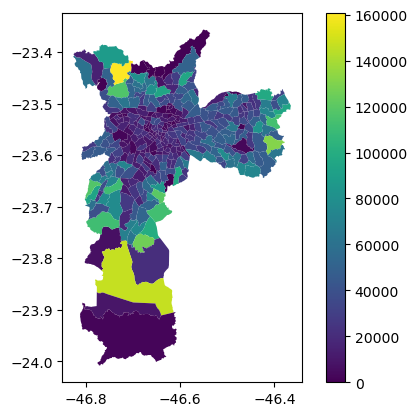

In [5]:
# Carrega o shapefile com as regiões (zonas ou subprefeituras)
# e os dados de população associados a cada região
mapa = gpd.read_file(f'{_base_map}/{identificacao}/map.shp')
pop = pd.read_csv(f'{_base_map}/{identificacao}/pop.csv')

pop = pop[pop['id'] != "Brazil"]

# Associa a população a cada geometria do mapa usando o ID
# Isso será usado depois para análises estruturais (ex: grau vs população)

mapa['pop'] = mapa['id'].map(lambda x: pop.set_index('id')['pop'].get(x,np.nan))

mapa.plot('pop', cmap='viridis', legend=True)

In [6]:
mapa.head()

,id,geometry,pop
0,Sé,"POLYGON ((-46.62782 -23.55166, -46.62763 -23.5...",3513
1,Parque Dom Pedro,"POLYGON ((-46.63526 -23.54296, -46.63512 -23.5...",4142
2,Praça João Mendes,"POLYGON ((-46.633 -23.55646, -46.63413 -23.556...",16177
3,Ladeira da Memória,"POLYGON ((-46.63889 -23.54861, -46.63889 -23.5...",24406
4,República,"POLYGON ((-46.63647 -23.54442, -46.63627 -23.5...",14734


In [7]:
# abrir matrizes
fn_move_mat = f'{_base_mob}/date0=<DATE>/move_mat_Brasil_{identificacao}'

def get_data(fn, date):
    _fn = fn.replace('<DATE>', date)
    #print(_fn)
    return np.load(f'{_fn}.npy').astype(float)

dates = list(pd.date_range('2019-01-01','2019-12-31').astype(str))

move_mat = get_data(fn_move_mat, dates[0])
for i in range(1,len(dates)):
    try:
        move_mat += get_data(fn_move_mat, dates[i])
    except:
        pass

move_mat_reg = [x.strip() for x in open(f'{fn_move_mat.replace("<DATE>",dates[0])}_reg_names.txt').readlines()]

assert set(move_mat_reg) == set(pop['id'])
assert set(mapa['id']) == set(pop['id'])

In [8]:
move_mat

array([[3.650000e+02, 0.000000e+00, 0.000000e+00, ..., 0.000000e+00,
        0.000000e+00, 0.000000e+00],
       [0.000000e+00, 2.124971e+06, 0.000000e+00, ..., 1.640000e+02,
        5.000000e+01, 1.710000e+02],
       [0.000000e+00, 0.000000e+00, 3.650000e+02, ..., 0.000000e+00,
        0.000000e+00, 0.000000e+00],
       ...,
       [0.000000e+00, 1.480000e+02, 0.000000e+00, ..., 1.262049e+06,
        3.790000e+02, 8.700000e+02],
       [0.000000e+00, 4.900000e+01, 0.000000e+00, ..., 3.960000e+02,
        5.763460e+05, 2.507000e+03],
       [0.000000e+00, 1.760000e+02, 0.000000e+00, ..., 1.005000e+03,
        2.634000e+03, 1.541032e+06]], shape=(343, 343))

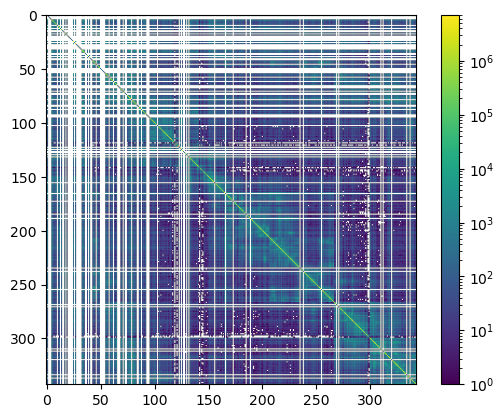

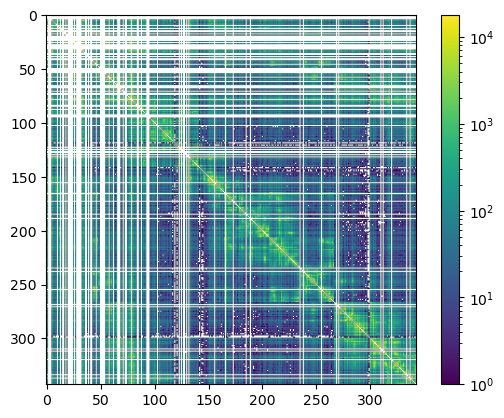

In [9]:
out_diagonal = move_mat.copy()
np.fill_diagonal(out_diagonal, 0.0)

plt.imshow(move_mat, norm='log')
plt.colorbar()
plt.show()
plt.clf()
plt.imshow(out_diagonal, norm='log')
plt.colorbar()
plt.show()

In [10]:
move_mat[7,:]

array([0.00000e+00, 1.90000e+02, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       3.45000e+02, 3.60000e+02, 3.47488e+05, 4.43000e+02, 2.46000e+02,
       0.00000e+00, 1.20000e+02, 1.26000e+02, 0.00000e+00, 6.60000e+01,
       0.00000e+00, 0.00000e+00, 1.11000e+02, 0.00000e+00, 4.60000e+01,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       1.50000e+02, 0.00000e+00, 1.43000e+02, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 1.36000e+02, 2.50000e+02,
       3.16000e+02, 0.00000e+00, 0.00000e+00, 7.30000e+01, 0.00000e+00,
       1.01000e+02, 0.00000e+00, 0.00000e+00, 4.50000e+01, 9.30000e+01,
       2.60000e+01, 0.00000e+00, 8.50000e+01, 2.30000e+01, 3.40000e+01,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       4.70000e+01, 7.00000e+01, 5.30000e+01, 0.00000e+00, 3.10000e+01,
       1.28000e+02, 8.90000e+01, 0.00000e+00, 4.20000e+01, 1.20000e+01,
       7.80000e+01, 0.00000e+00, 0.00000e+00, 0.00000e+00, 3.300

In [11]:
move_mat_reg

['Sé',
 'Parque Dom Pedro',
 'Praça João Mendes',
 'Ladeira da Memória',
 'República',
 'Santa Ifigênia',
 'Luz',
 'Bom Retiro',
 'Ponte Pequena',
 'Canindé',
 'Bom Jardim',
 'Pari',
 'João Teodoro',
 'Oriente',
 'Bresser',
 'Brás',
 'Gasômetro',
 'Independência',
 'Cambuci',
 'Glicério',
 'Aclimação',
 'Pires da Mota',
 'Centro Cultural',
 'Liberdade',
 'Treze de Maio',
 'Bexiga',
 'Bela Vista',
 'São Carlos do Pinhal',
 'Masp',
 'Higienópolis',
 'Vila Buarque',
 'Consolação',
 'Pacaembu',
 'FAAP',
 'Santa Cecília',
 'Marechal Deodoro',
 'Rudge',
 'Catumbi',
 'Belém',
 'Quarta Parada',
 'Belenzinho',
 'Celso Garcia',
 'Mooca',
 'Alto da Mooca',
 'Parque da Mooca',
 'Água Rasa',
 'Vila Bertioga',
 'Regente Feijó',
 'Ana Rosa',
 'Jardim da Glória',
 'Chácara Klabin',
 'Vila Mariana',
 'Santa Cruz',
 'Vila Clementino',
 'França Pinto',
 'Rodrigues Alves',
 'Paraíso',
 'Bosque da Saúde',
 'Saúde',
 'Planalto Paulista',
 'Mirandópolis',
 'Parque Ibirapuera',
 'Jardim Luzitânia',
 'Moema',


In [12]:
move_mat.shape

(343, 343)

In [13]:
# Constrói o grafo direcionado/ponderado a partir da matriz de mobilidade
# Nós = regiões
# Arestas = fluxo de pessoas entre regiões
# Peso = intensidade do fluxo

G = nx.from_numpy_array(move_mat, create_using=nx.DiGraph)

# atributo com nome/ID da região
node_attrs = {i: {'id': move_mat_reg[i]} for i in range(len(move_mat_reg))}
nx.set_node_attributes(G, node_attrs)

In [14]:
G.nodes[0]

{'id': 'Sé'}

In [15]:
# precisa de grafo não-direcionado
G_und = G.to_undirected()

G_und.remove_edges_from(nx.selfloop_edges(G_und))

# Detecção de comunidades usando algoritmo de Louvain
# Objetivo: identificar grupos de regiões com forte interação interna
partition = community_louvain.best_partition(G_und, weight='weight',resolution=0.3)

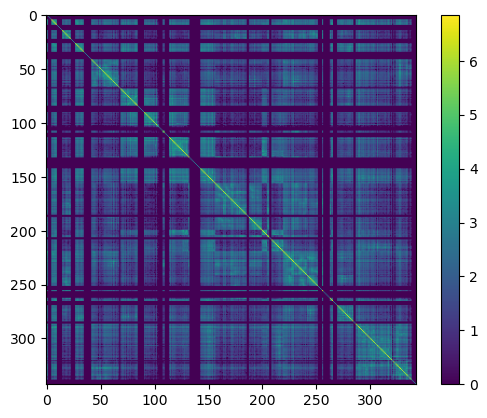

In [16]:
order = sorted(range(len(partition)), key=lambda x: partition[x])
mat_sorted = move_mat[order][:, order]

plt.imshow(np.log10(mat_sorted + 1))
plt.colorbar()

In [17]:
df_comm = pd.DataFrame({
    "id": move_mat_reg,
    "community": [partition[i] for i in range(len(move_mat_reg))]
})

In [18]:
gdf_comm = mapa.merge(df_comm, on="id", how="left")
gdf_comm = gdf_comm[~gdf_comm['id'].str.contains('#')]
#gdf_comm

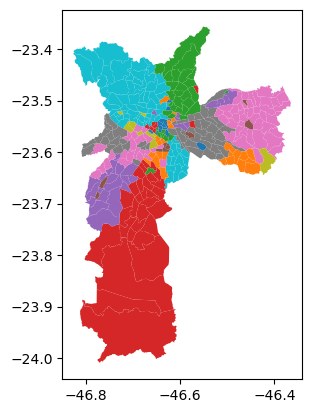

In [19]:
gdf_comm.plot(column="community", categorical=True, legend=False)
plt.show()

0


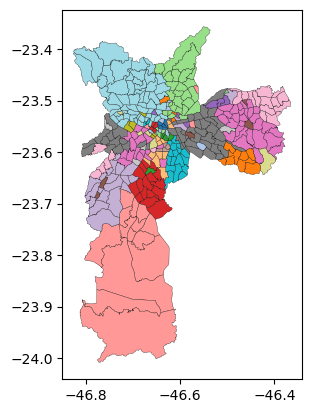

In [20]:
gdf_comm.plot(
    column="community",
    categorical=True,
    legend=False,
    cmap="tab20",
    edgecolor="black",
    linewidth=0.2
)
print(gdf_comm["community"].isna().sum())

<Axes: >

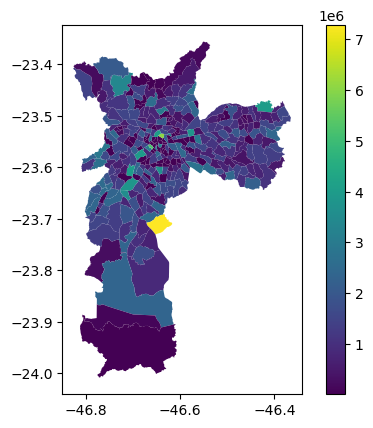

In [21]:
gdf_comm["out_strength"] = gdf_comm["id"].map(
    dict(zip(move_mat_reg, move_mat.sum(axis=1)))
)

gdf_comm.plot(column="out_strength", cmap="viridis", legend=True)

<Axes: >

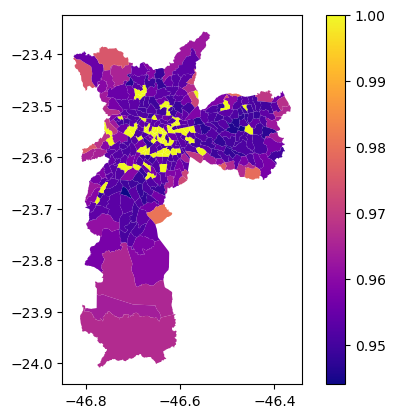

In [22]:
diag = np.diag(move_mat)
out = move_mat.sum(axis=1)

ret = diag / (out + 1e-12)

gdf_comm["retention"] = gdf_comm["id"].map(
    dict(zip(move_mat_reg, ret))
)

gdf_comm.plot(column="retention", cmap="plasma", legend=True)

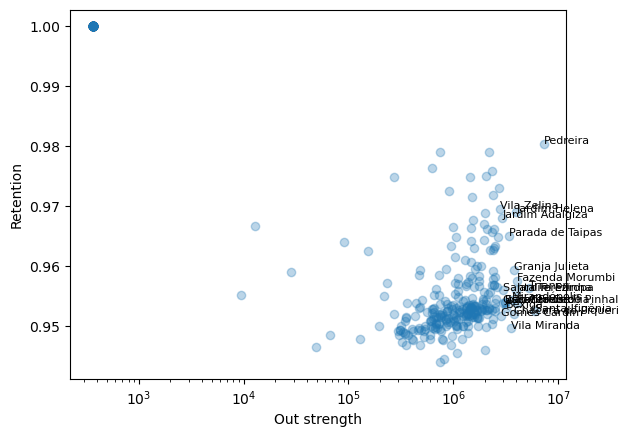

In [23]:
# soma das saídas (linha)
out_strength = move_mat.sum(axis=1)

# diagonal
diag = np.diag(move_mat)

# retenção
retention = diag / (out_strength + 1e-12)

# plot
#plt.scatter(out_strength, retention, alpha=0.5)

#for i, name in enumerate(move_mat_reg):
#    plt.text(out_strength[i], retention[i], name, fontsize=6)


idx = np.argsort(out_strength)[-20:]

plt.scatter(out_strength, retention, alpha=0.3)

for i in idx:
    plt.text(out_strength[i], retention[i], move_mat_reg[i], fontsize=8)


plt.xscale('log')
plt.xlabel("Out strength")
plt.ylabel("Retention")
plt.show()

In [24]:
dates = list(pd.date_range('2019-01-01','2019-12-31').astype(str))

total_mobility = []

for d in dates:
    try:
        mat = get_data(fn_move_mat, d)
        # mobilidade total excluindo permanências (diagonal)
        total_mobility.append(mat.sum() - np.trace(mat))
    except:
        total_mobility.append(np.nan)

mob_df = pd.DataFrame({"date": dates, "total_mobility": total_mobility})
mob_df["date"] = pd.to_datetime(mob_df["date"])

<Axes: xlabel='date'>

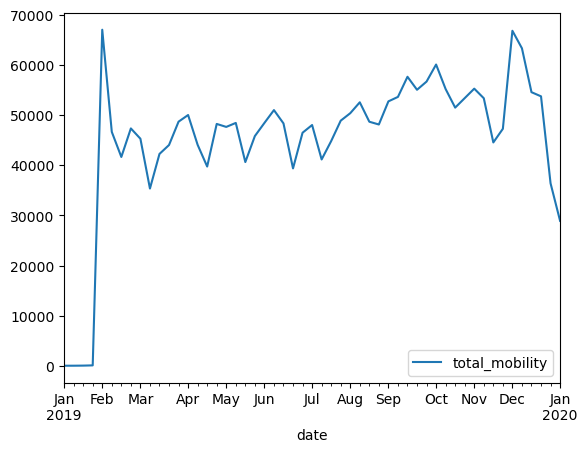

In [25]:
mob_df.set_index("date").resample("W").mean().plot()

In [26]:
dates = list(pd.date_range('2019-01-01','2019-12-31').astype(str))

# lista de regiões sem ids “#”
valid_idx = [i for i, x in enumerate(move_mat_reg) if '#' not in x]
valid_regions = [move_mat_reg[i] for i in valid_idx]

# listas para construir DataFrame
records = []

for d in dates:
    try:
        mat = get_data(fn_move_mat, d)
        # filtrar apenas regiões válidas
        mat = mat[np.ix_(valid_idx, valid_idx)]

        total_mob = mat.sum() - np.trace(mat)
        out_strength = mat.sum(axis=1)
        in_strength  = mat.sum(axis=0)
        diag = np.diag(mat)
        retention = diag / (out_strength + 1e-12)
        flow_rel = out_strength / (total_mob + 1e-12)

        for i, reg in enumerate(valid_regions):
            records.append({
                "date": pd.to_datetime(d),
                "id": reg,
                "total_mobility": total_mob,
                "out_strength": out_strength[i],
                "in_strength": in_strength[i],
                "retention": retention[i],
                "flow_rel": flow_rel[i]
            })

    except Exception as e:
        # caso falhe, coloca NaNs
        for reg in valid_regions:
            records.append({
                "date": pd.to_datetime(d),
                "id": reg,
                "total_mobility": np.nan,
                "out_strength": np.nan,
                "in_strength": np.nan,
                "retention": np.nan,
                "flow_rel": np.nan
            })

# criar DataFrame final
mob_region_df = pd.DataFrame(records)

# aplicar filtro extra (caso queira)
mob_region_df = mob_region_df[~mob_region_df['id'].str.contains('#')]

# setar a data como índice
mob_region_df = mob_region_df.set_index("date")

# resample por mês e agrupar por região
mob_region_df = mob_region_df.groupby("id").resample("W").mean().reset_index()

mob_region_df.head()

,id,date,total_mobility,out_strength,in_strength,retention,flow_rel
0,Aclimação,2019-01-06,23.166667,1.0,1.0,1.0,0.045719
1,Aclimação,2019-01-13,26.571429,1.0,1.0,1.0,0.040313
2,Aclimação,2019-01-20,44.857143,1.0,1.0,1.0,0.026486
3,Aclimação,2019-01-27,92.428571,1.0,1.0,1.0,0.011456
4,Aclimação,2019-02-03,67045.000000,1.0,1.0,1.0,0.001363


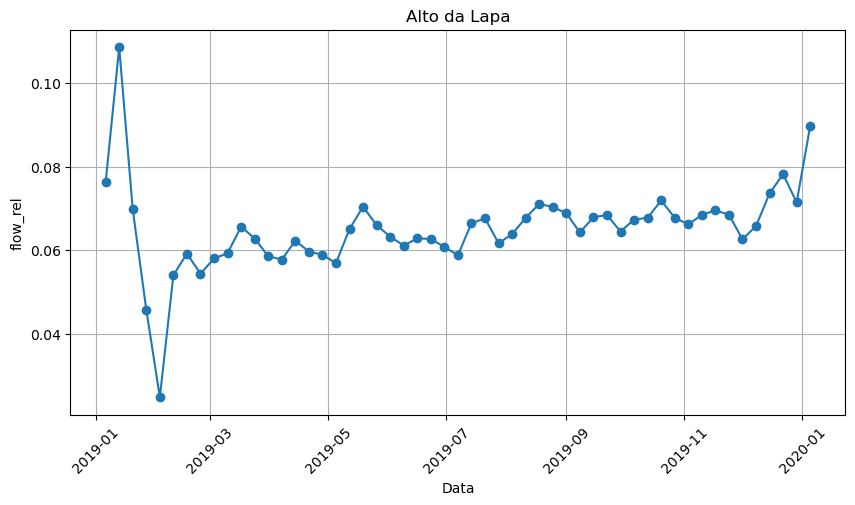

In [27]:
col = 'flow_rel'

# escolher região
region = "Alto da Lapa"  # ou qualquer id do seu DataFrame
df_reg = mob_region_df[mob_region_df['id'] == region]

plt.figure(figsize=(10,5))
plt.plot(df_reg['date'], df_reg[col], marker='o')
plt.title(f"{region}")
plt.xlabel("Data")
plt.ylabel(col)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

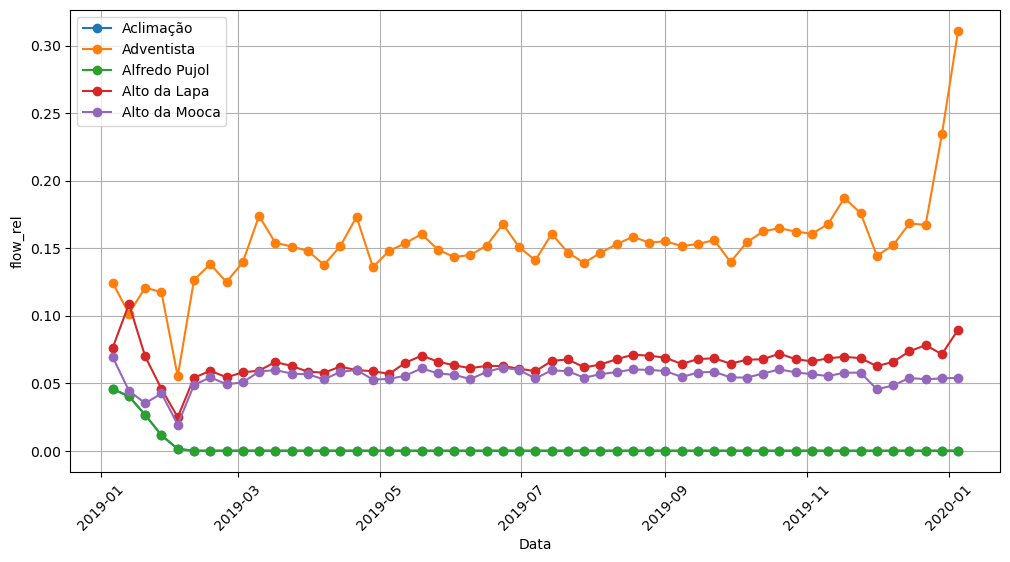

In [28]:
top_regions = mob_region_df.groupby("id")['total_mobility'].mean().sort_values(ascending=False).head(5).index

plt.figure(figsize=(12,6))
for reg in top_regions:
    df_reg = mob_region_df[mob_region_df['id'] == reg]
    plt.plot(df_reg['date'], df_reg['flow_rel'], marker='o', label=reg)

#plt.title("Mobilidade total mensal - top 5 regiões")
plt.xlabel("Data")
plt.ylabel("flow_rel")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

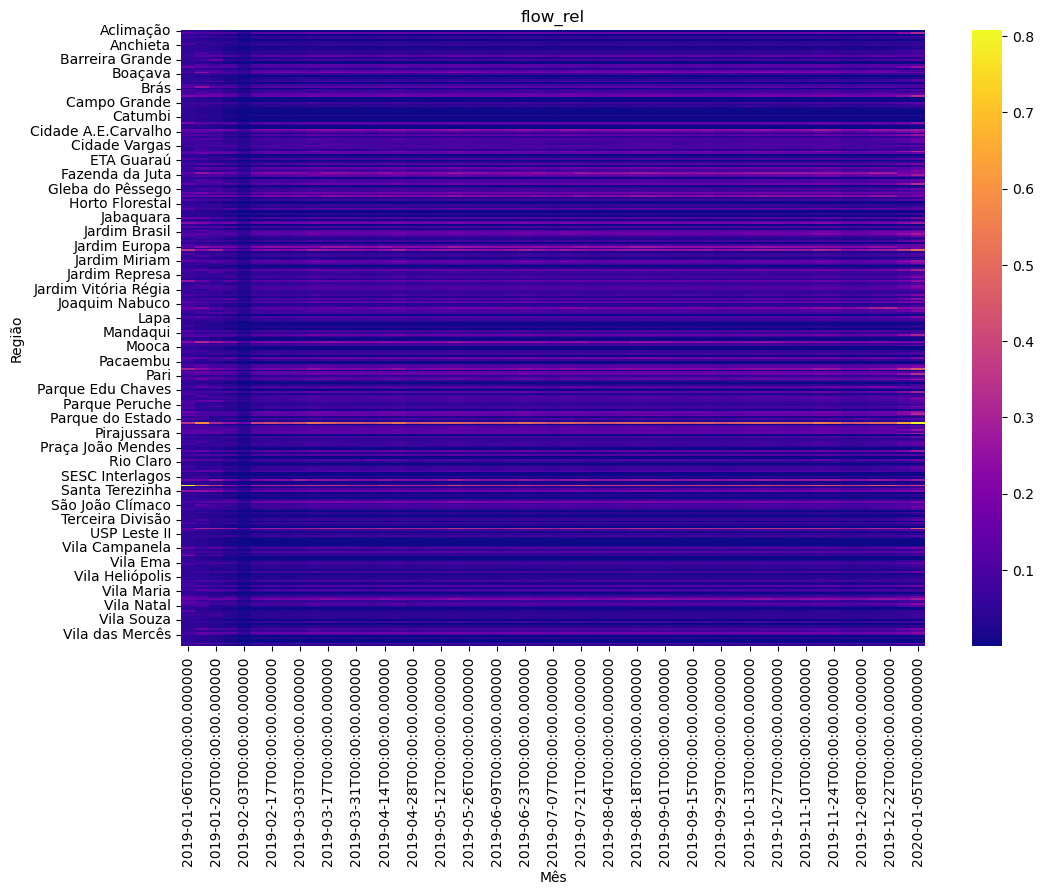

In [29]:
# pivot: linhas = meses, colunas = regiões
mob_pivot = mob_region_df.pivot_table(index='date', columns='id', values='flow_rel')

plt.figure(figsize=(12,8))
sns.heatmap(mob_pivot.T, cmap="plasma")
plt.title("flow_rel")
plt.xlabel("Mês")
plt.ylabel("Região")
plt.show()

### Novas Análises

#### 2.1 Estatísticas descritivas + mapas

In [30]:
mapa

,id,geometry,pop
0,Sé,"POLYGON ((-46.62782 -23.55166, -46.62763 -23.5...",3513
1,Parque Dom Pedro,"POLYGON ((-46.63526 -23.54296, -46.63512 -23.5...",4142
2,Praça João Mendes,"POLYGON ((-46.633 -23.55646, -46.63413 -23.556...",16177
3,Ladeira da Memória,"POLYGON ((-46.63889 -23.54861, -46.63889 -23.5...",24406
4,República,"POLYGON ((-46.63647 -23.54442, -46.63627 -23.5...",14734
...,...,...,...
338,Jaguaré,"POLYGON ((-46.74461 -23.55841, -46.74494 -23.5...",33885
339,Cidade Universitária,"POLYGON ((-46.74444 -23.55842, -46.74431 -23.5...",2283
340,Butantã,"POLYGON ((-46.72311 -23.57253, -46.72313 -23.5...",6873
341,Jardim Caxingui,"POLYGON ((-46.72698 -23.57409, -46.72551 -23.5...",8514


In [31]:
G.nodes[1]

{'id': 'Parque Dom Pedro'}

In [32]:
grau = dict(G.degree(weight='weight'))

# pega os ids dos nós
node_ids = nx.get_node_attributes(G, 'id')

df = pd.DataFrame({
    'node': list(G.nodes()),
    'grau': list(grau.values())
})

df['id'] = df['node'].map(node_ids)

# agora sim junta com o mapa
mapa = mapa.merge(df[['id', 'grau']], on='id', how='left')

In [33]:
mapa

,id,geometry,pop,grau
0,Sé,"POLYGON ((-46.62782 -23.55166, -46.62763 -23.5...",3513,730.0
1,Parque Dom Pedro,"POLYGON ((-46.63526 -23.54296, -46.63512 -23.5...",4142,4457207.0
2,Praça João Mendes,"POLYGON ((-46.633 -23.55646, -46.63413 -23.556...",16177,730.0
3,Ladeira da Memória,"POLYGON ((-46.63889 -23.54861, -46.63889 -23.5...",24406,730.0
4,República,"POLYGON ((-46.63647 -23.54442, -46.63627 -23.5...",14734,730.0
...,...,...,...,...
338,Jaguaré,"POLYGON ((-46.74461 -23.55841, -46.74494 -23.5...",33885,4030191.0
339,Cidade Universitária,"POLYGON ((-46.74444 -23.55842, -46.74431 -23.5...",2283,2986428.0
340,Butantã,"POLYGON ((-46.72311 -23.57253, -46.72313 -23.5...",6873,2659762.0
341,Jardim Caxingui,"POLYGON ((-46.72698 -23.57409, -46.72551 -23.5...",8514,1212596.0


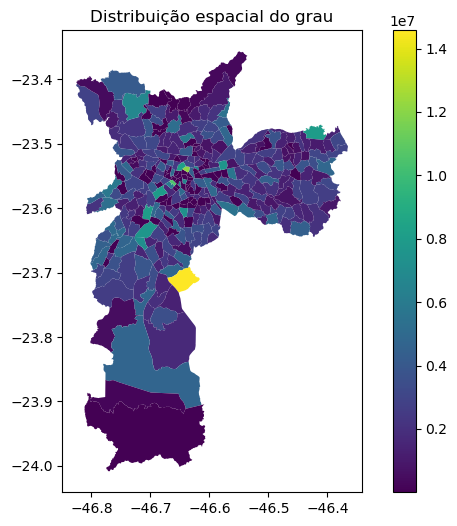

In [34]:
mapa.plot(column='grau', legend=True, figsize=(8,6))
plt.title('Distribuição espacial do grau')
plt.show()

### Distribuição dos graus (histograma)

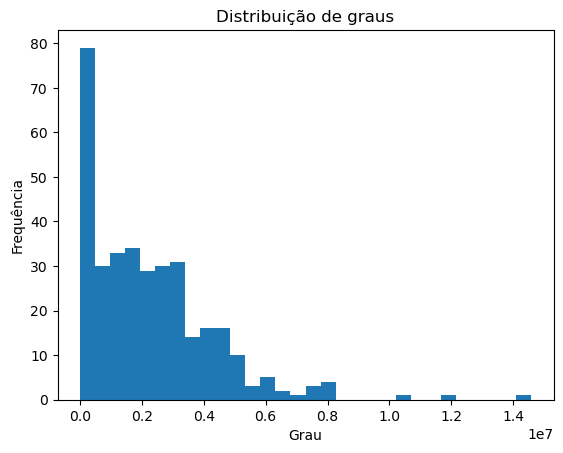

In [35]:
graus = list(grau.values())

plt.hist(graus, bins=30)
plt.title('Distribuição de graus')
plt.xlabel('Grau')
plt.ylabel('Frequência')
plt.show()

# opcional (melhor pra ver cauda)
# sns.histplot(graus, log_scale=True)

### População x Grau

In [36]:
mapa

,id,geometry,pop,grau
0,Sé,"POLYGON ((-46.62782 -23.55166, -46.62763 -23.5...",3513,730.0
1,Parque Dom Pedro,"POLYGON ((-46.63526 -23.54296, -46.63512 -23.5...",4142,4457207.0
2,Praça João Mendes,"POLYGON ((-46.633 -23.55646, -46.63413 -23.556...",16177,730.0
3,Ladeira da Memória,"POLYGON ((-46.63889 -23.54861, -46.63889 -23.5...",24406,730.0
4,República,"POLYGON ((-46.63647 -23.54442, -46.63627 -23.5...",14734,730.0
...,...,...,...,...
338,Jaguaré,"POLYGON ((-46.74461 -23.55841, -46.74494 -23.5...",33885,4030191.0
339,Cidade Universitária,"POLYGON ((-46.74444 -23.55842, -46.74431 -23.5...",2283,2986428.0
340,Butantã,"POLYGON ((-46.72311 -23.57253, -46.72313 -23.5...",6873,2659762.0
341,Jardim Caxingui,"POLYGON ((-46.72698 -23.57409, -46.72551 -23.5...",8514,1212596.0


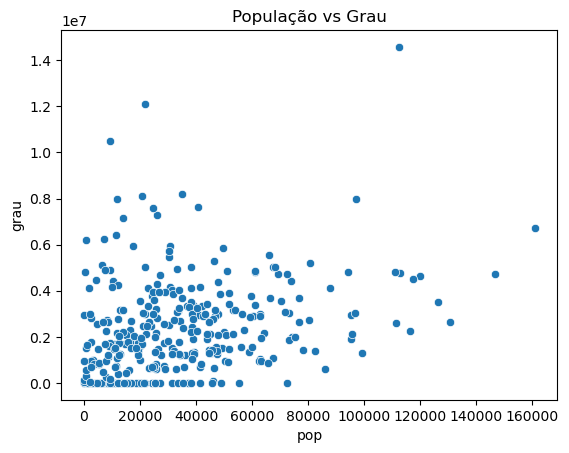

In [37]:
df_aux = mapa[['id', 'pop', 'grau']].copy()
# df_aux['grau'] = df_aux['id'].map(grau)

sns.scatterplot(data=df_aux, x='pop', y='grau')
plt.title('População vs Grau')
plt.show()

### Grau × coeficiente de aglomeração (hierarquia)

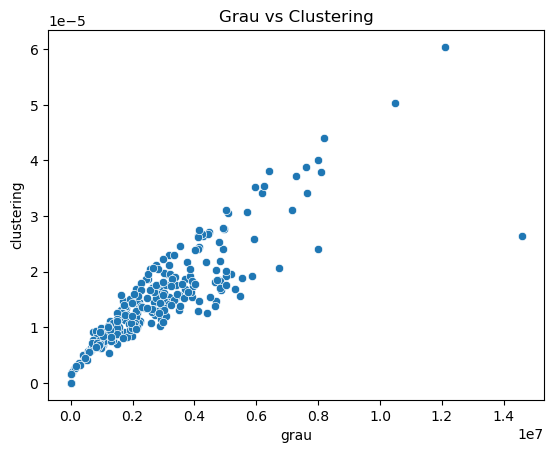

In [38]:
clustering = nx.clustering(G, weight='weight')

df_aux = pd.DataFrame({
    'grau': grau,
    'clustering': clustering
})

sns.scatterplot(data=df_aux, x='grau', y='clustering')
plt.title('Grau vs Clustering')
plt.show()

### Comunidades → consistência espacial

In [39]:
partition = community_louvain.best_partition(G, weight='weight')
mapa['comunidade'] = mapa['id'].map(partition)

mapa.plot(column='comunidade', categorical=True, legend=True, figsize=(8,6))
plt.title('Comunidades detectadas')
plt.show()

TypeError: Bad graph type, use only non directed graph